In [1]:
from datasets import load_dataset, load_from_disk
from typing import List, Tuple, Union
import gc
import json
import gc
import pandas as pd

BASE_PATH = "../../data/qa_datasets/"
DATASET_DIR_NAME = "natural_questions_train"

SAVE_DATASET_PATH = f"{BASE_PATH}/{DATASET_DIR_NAME}/original"
SAVE_TMP_CONTEXTS_PATH = f"{BASE_PATH}/{DATASET_DIR_NAME}/tmp_natural_questions_cntx.csv"
SAVE_CONTEXTS_PATH = f"{BASE_PATH}/{DATASET_DIR_NAME}/relevant_contexts.csv"
SAVE_QA_PATH = f"{BASE_PATH}/{DATASET_DIR_NAME}/qa_pairs.csv"
SAVE_STATS_PATH = f"{BASE_PATH}/{DATASET_DIR_NAME}/stats.json"

DOC_MAX_LEN = 1024
DOC_MIN_LEN = 64
MAX_QA_PAIRS = 2000
NOISE_DOCUMENTS_AMOUNT = 2000

/home/dzigen/Desktop/Projects/PersonalAI/.pai_venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from utils import preprocess_documents, plot_textlen_distribution, \
    preprocess_qapairs, select_noise_documents, calculate_dataset_stats, \
        check_dataset_consistency, calculate_original_dataset_stats

In [ ]:
original_dataset = load_dataset("sentence-transformers/natural-questions", split="train") # 6k
original_dataset.save_to_disk(SAVE_DATASET_PATH)

In [ ]:
original_dataset

In [3]:
original_dataset = load_from_disk(SAVE_DATASET_PATH)

In [4]:
original_dataset

Dataset({
    features: ['query', 'answer'],
    num_rows: 100231
})

In [5]:
def get_question_documents(dataset: object, idx: int) -> List[Tuple[Union[None,str], str]]: 
    title = None
    text = dataset['answer'][idx]
    return [(title, text)]

def get_dataset_len(dataset: object) -> int:
    return len(dataset)

def get_qa_info(dataset: object, idx: int) -> Tuple[str, str, str, List[Tuple[Union[None, str], str]]]:
    question_type = None
    question, answer = dataset['query'][idx], dataset['answer'][idx]
    relevant_documents = [(None, dataset['answer'][idx])]
    return question, question_type, answer, relevant_documents

In [6]:
CUSTOM_FUNCS = {
    'get_question_documents': get_question_documents,
    'get_dataset_len': get_dataset_len,
    'get_qa_info': get_qa_info
}

In [7]:
calculate_original_dataset_stats(original_dataset, CUSTOM_FUNCS)

100%|██████████| 100231/100231 [01:56<00:00, 859.69it/s]


Questions (with duplications):
{'median': 45.0, 'mean': 47.21118, 'std': 10.89939, 'min': 19, 'max': 100, 'count': 100231}
Questions (w/o duplications):
{'median': 45.0, 'mean': 47.21118, 'std': 10.89939, 'min': 19, 'max': 100, 'count': 100231}
Answers (with duplications):
{'median': 549.0, 'mean': 612.70603, 'std': 345.07296, 'min': 10, 'max': 13462, 'count': 100231}
Answers (w/o duplications):
{'median': 548.0, 'mean': 613.75243, 'std': 352.48243, 'min': 10, 'max': 13462, 'count': 75215}
Documents (with duplications):  100231
Documents (w/o duplications):  75215
Documents per questions: 
{'median': 1.0, 'mean': 1.0, 'std': 0.0, 'min': 1, 'max': 1, 'count': 100231}


### Preprocessing documents

In [8]:
accepted_documents_df = preprocess_documents(
    original_dataset, DOC_MIN_LEN, DOC_MAX_LEN, CUSTOM_FUNCS)

100%|██████████| 100231/100231 [00:30<00:00, 3317.69it/s]


In [ ]:
accepted_documents_df.to_csv(SAVE_TMP_CONTEXTS_PATH, index=False)

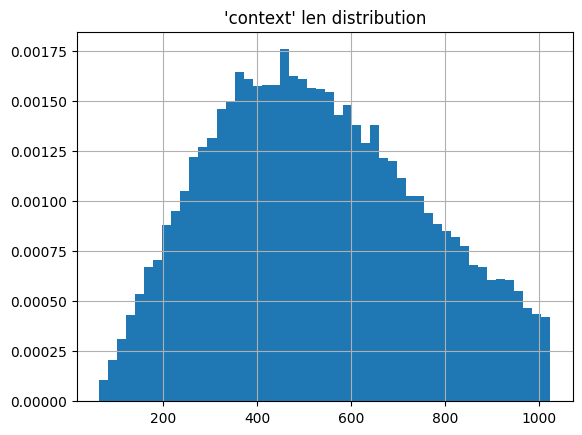

In [9]:
plot_textlen_distribution(accepted_documents_df, 'context')

In [10]:
accepted_documents_df.head()

,title,context,hash,original_qaidx
0,None,"Jack Scott (singer) At the beginning of 1960, ...",2b2bbb5056e76c4d5ab2ea949df7c13d,1
1,None,Wool Global wool production is about 2 million...,6e378d38740c5ec9bf895820082a8160,2
2,None,Alaska: The Last Frontier Alaska: The Last Fro...,7cb97a2c3a7a5ddee8625f8549e8827a,3
3,None,All I Want (A Day to Remember song) The music ...,ce788d09697e6471ee253c211cda3fd8,4
4,None,Flag of the United States The flag of the Unit...,4f23468e8d7740a47058147a4b9c362b,5


In [11]:
accepted_documents_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67174 entries, 0 to 67173
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   title           0 non-null      object
 1   context         67174 non-null  object
 2   hash            67174 non-null  object
 3   original_qaidx  67174 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 2.1+ MB


In [12]:
accepted_documents_df.shape

(67174, 4)

### Preprocessing QA pairs

In [13]:
qapairs_df, relevant_documents_df = preprocess_qapairs(
    original_dataset, accepted_documents_df, MAX_QA_PAIRS, CUSTOM_FUNCS)

  2%|▏         | 2251/100231 [00:02<01:28, 1111.22it/s]


In [ ]:
qapairs_df.to_csv(SAVE_QA_PATH, index=False)

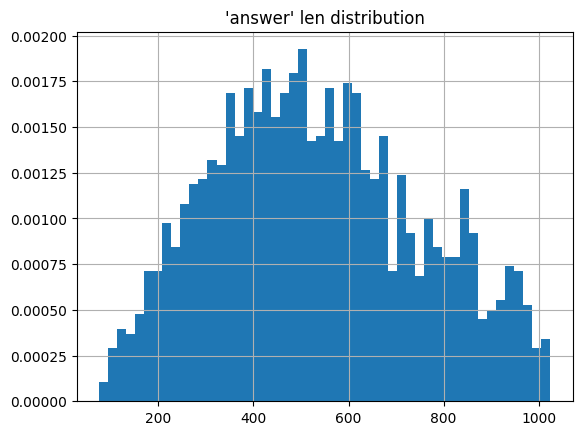

In [14]:
plot_textlen_distribution(qapairs_df, 'answer')

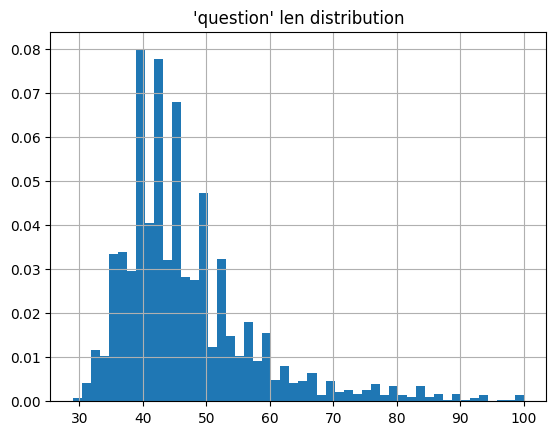

In [15]:
plot_textlen_distribution(qapairs_df, 'question')

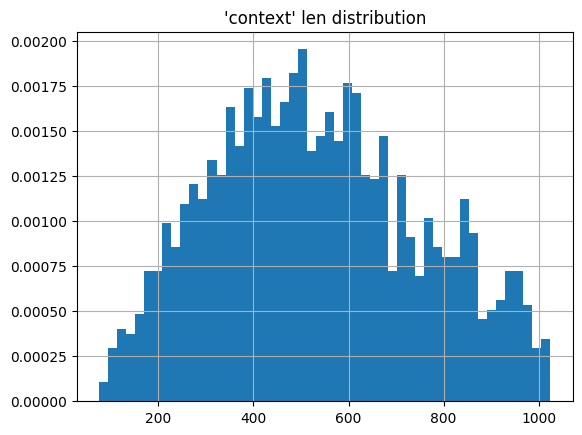

In [16]:
plot_textlen_distribution(relevant_documents_df, 'context')

In [17]:
qapairs_df

,question,type,answer,cntx_ids,qa_idx,original_qaidx
0,who sang what in the world's come over you,None,"Jack Scott (singer) At the beginning of 1960, ...",[0],0,1
1,who produces the most wool in the world,None,Wool Global wool production is about 2 million...,[1],1,2
2,where does alaska the last frontier take place,None,Alaska: The Last Frontier Alaska: The Last Fro...,[2],2,3
3,a day to remember all i want cameos,None,All I Want (A Day to Remember song) The music ...,[3],3,4
4,what does the red stripes mean on the american...,None,Flag of the United States The flag of the Unit...,[4],4,5
...,...,...,...,...,...,...
1995,who was the first child born after migration (...,None,Abd Allah ibn al-Zubayr Abd Allah ibn al-Zubay...,[1965],1995,2245
1996,according to piaget the second stage of cognit...,None,Piaget's theory of cognitive development In hi...,[1966],1996,2246
1997,key characteristics of the anglo saxon model m...,None,Anglo-Saxon model Characteristics of this mode...,[1967],1997,2248
1998,how many under the dome books are there,None,Under the Dome (novel) Under the Dome is a sci...,[1968],1998,2249


In [18]:
qapairs_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   question        2000 non-null   object
 1   type            0 non-null      object
 2   answer          2000 non-null   object
 3   cntx_ids        2000 non-null   object
 4   qa_idx          2000 non-null   int64 
 5   original_qaidx  2000 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 93.9+ KB


In [19]:
qapairs_df.shape

(2000, 6)

In [20]:
relevant_documents_df

,title,context,cntx_idx,hash
0,None,"Jack Scott (singer) At the beginning of 1960, ...",0,2b2bbb5056e76c4d5ab2ea949df7c13d
1,None,Wool Global wool production is about 2 million...,1,6e378d38740c5ec9bf895820082a8160
2,None,Alaska: The Last Frontier Alaska: The Last Fro...,2,7cb97a2c3a7a5ddee8625f8549e8827a
3,None,All I Want (A Day to Remember song) The music ...,3,ce788d09697e6471ee253c211cda3fd8
4,None,Flag of the United States The flag of the Unit...,4,4f23468e8d7740a47058147a4b9c362b
...,...,...,...,...
1965,None,Abd Allah ibn al-Zubayr Abd Allah ibn al-Zubay...,1965,a1856dd924e817661a21b34e8c086998
1966,None,Piaget's theory of cognitive development In hi...,1966,a1febc8506ecb4023ab2dcebf74c0197
1967,None,Anglo-Saxon model Characteristics of this mode...,1967,102e1e834d65e75886c31163f6e25120
1968,None,Under the Dome (novel) Under the Dome is a sci...,1968,1ddf19f655dab397ae82b792142be350


In [21]:
relevant_documents_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1970 entries, 0 to 1969
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   title     0 non-null      object
 1   context   1970 non-null   object
 2   cntx_idx  1970 non-null   int64 
 3   hash      1970 non-null   object
dtypes: int64(1), object(3)
memory usage: 61.7+ KB


In [22]:
relevant_documents_df.shape

(1970, 4)

### Expanding relevant documents dataframe by noise documents

In [23]:
DOCIDX_OFFSET = max(relevant_documents_df['cntx_idx'].tolist()) + 1
print(DOCIDX_OFFSET)
noise_documents_df = select_noise_documents(
    relevant_documents_df, accepted_documents_df, 
    NOISE_DOCUMENTS_AMOUNT, DOCIDX_OFFSET, CUSTOM_FUNCS)

expanded_relevant_documents_df = pd.concat([relevant_documents_df, noise_documents_df], ignore_index=True)

1970


2000it [00:07, 251.51it/s]


In [ ]:
expanded_relevant_documents_df.to_csv(SAVE_CONTEXTS_PATH, index=False)

In [24]:
noise_documents_df

,title,context,cntx_idx,hash
0,None,Deep Blue Sea 2 Deep Blue Sea 2 is a science f...,1970,4f392e5454a0a79b6e0427383b2558f0
1,None,Wernicke's area Wernicke's area (/ˈvɛərnɪkə/ o...,1971,9b88a8c1b1f394090e695b09ed8750cf
2,None,Hungarian alphabet The 44 letters of the exten...,1972,fd8eda6ea25d0843d7b49407a728fd33
3,None,Health care in the United States Health care i...,1973,3ef84617f25e95227fc3145aa2d52261
4,None,"Democratic Party of Georgia Since 1948, the De...",1974,f7d7e4b6eb6f3bd3f1d727dd32779b03
...,...,...,...,...
1995,None,"Res ipsa loquitur In the common law of torts, ...",3965,6049f339ff864d099a4d7730395e67e7
1996,None,Steve Dalkowski According to the Guinness Book...,3966,44263b60a5f62d06c6a11c88b53d7fbf
1997,None,List of Disney's Beauty and the Beast characte...,3967,1ce5521b9f83c50425d3cf559d00ffd2
1998,None,"History of film In the 1890s, films were seen ...",3968,0c06ba0ff6bf89b24ab619c5ee8ee8aa


In [25]:
noise_documents_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   title     0 non-null      object
 1   context   2000 non-null   object
 2   cntx_idx  2000 non-null   int64 
 3   hash      2000 non-null   object
dtypes: int64(1), object(3)
memory usage: 62.6+ KB


In [26]:
noise_documents_df.shape

(2000, 4)

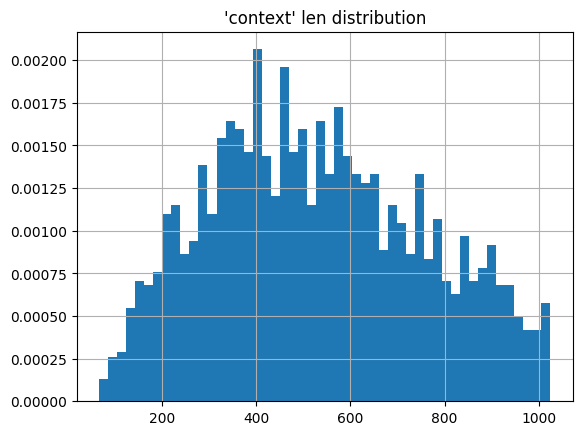

In [27]:
plot_textlen_distribution(noise_documents_df, 'context')

In [28]:
expanded_relevant_documents_df

,title,context,cntx_idx,hash
0,None,"Jack Scott (singer) At the beginning of 1960, ...",0,2b2bbb5056e76c4d5ab2ea949df7c13d
1,None,Wool Global wool production is about 2 million...,1,6e378d38740c5ec9bf895820082a8160
2,None,Alaska: The Last Frontier Alaska: The Last Fro...,2,7cb97a2c3a7a5ddee8625f8549e8827a
3,None,All I Want (A Day to Remember song) The music ...,3,ce788d09697e6471ee253c211cda3fd8
4,None,Flag of the United States The flag of the Unit...,4,4f23468e8d7740a47058147a4b9c362b
...,...,...,...,...
3965,None,"Res ipsa loquitur In the common law of torts, ...",3965,6049f339ff864d099a4d7730395e67e7
3966,None,Steve Dalkowski According to the Guinness Book...,3966,44263b60a5f62d06c6a11c88b53d7fbf
3967,None,List of Disney's Beauty and the Beast characte...,3967,1ce5521b9f83c50425d3cf559d00ffd2
3968,None,"History of film In the 1890s, films were seen ...",3968,0c06ba0ff6bf89b24ab619c5ee8ee8aa


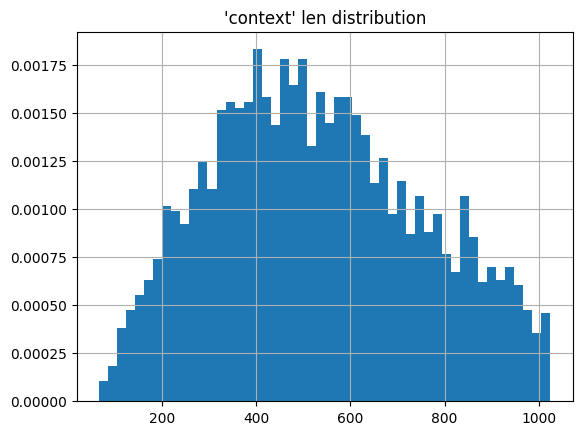

In [29]:
plot_textlen_distribution(expanded_relevant_documents_df, 'context')

### Calculating statistics

In [30]:
processed_dataset_stats = calculate_dataset_stats(qapairs_df, expanded_relevant_documents_df)
processed_dataset_stats['NOISE_DOCUMENTS_AMOUNT'] = NOISE_DOCUMENTS_AMOUNT

In [ ]:
with open(SAVE_STATS_PATH, 'w', encoding='utf-8') as fd:
    json.dump(processed_dataset_stats, fd, indent=1, ensure_ascii=False)

In [31]:
check_dataset_consistency(original_dataset, qapairs_df, expanded_relevant_documents_df, CUSTOM_FUNCS)

100%|██████████| 2000/2000 [00:02<00:00, 705.88it/s]


True

In [32]:
processed_dataset_stats

{'contexts_amount': 3970,
 'contexts_len': {'median': 514.0,
  'mean': 532.37683,
  'std': 222.96614,
  'min': 67,
  'max': 1024,
  'count': 3970},
 'qa_pairs_amount': 2000,
 'answers_len': {'median': 514.5,
  'mean': 533.52,
  'std': 217.9388,
  'min': 76,
  'max': 1024,
  'count': 2000},
 'questions_len': {'median': 44.0,
  'mean': 46.9905,
  'std': 10.88478,
  'min': 29,
  'max': 100,
  'count': 2000},
 'rel_contexts_per_question': {'median': 1.0,
  'mean': 1.0,
  'std': 0.0,
  'min': 1,
  'max': 1,
  'count': 2000},
 'NOISE_DOCUMENTS_AMOUNT': 2000}